# Scary Stochastics, Week 3: Brownian Motion
## Notebook 2 of 3 — Population Spread

This notebook is self-contained (same seed, same generation code as Notebook 1, plus a new population simulation). 180 people, each on their own independent Brownian walk around a town. One patient zero starts infected at the center. Infection spreads by proximity; infected individuals eventually recover (**cured**, shown in steel blue).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Zombie outbreak palette (extends the series palette with zombie green + cured steel blue)
PALETTE = {
    "red":    "#C8102E",  # candy red - patient zero marker
    "orange": "#E8741C",
    "rust":   "#B5451B",
    "purple": "#3B2145",
    "mustard":"#D9A404",
    "green":  "#6B8E23",  # zombie green - infected
    "blue":   "#4682B4",  # cured / steel blue - recovered
    "slate":  "#8C8C7A",  # susceptible - untouched humans
    "black":  "#1B1B1B",
    "cream":  "#FBF3E1",
}

STATE_NAMES = ["Susceptible", "Infected", "Recovered"]
STATE_COLORS = {"Susceptible": PALETTE["slate"], "Infected": PALETTE["green"], "Recovered": PALETTE["blue"]}

# Shared simulation constants
POP_SIZE = 180
TOWN_SIZE = 100.0
N_STEPS = 150
SIGMA = 1.5            # shambling step size (per-tick movement std)
CONTACT_RADIUS = 3.0
INFECTION_PROB = 0.15
RECOVERY_PROB = 0.02

plt.rcParams.update({
    "figure.facecolor": PALETTE["cream"],
    "axes.facecolor": PALETTE["cream"],
    "axes.edgecolor": PALETTE["black"],
    "text.color": PALETTE["black"],
    "axes.labelcolor": PALETTE["black"],
    "xtick.color": PALETTE["black"],
    "ytick.color": PALETTE["black"],
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

### Simulate the outbreak

In [2]:
# A town of 180 people, each doing their own independent Brownian walk.
# States: 0 = Susceptible, 1 = Infected, 2 = Recovered ("cured")
positions = np.random.uniform(0, TOWN_SIZE, size=(POP_SIZE, 2))
state = np.zeros(POP_SIZE, dtype=int)

patient_zero = 0
positions[patient_zero] = [TOWN_SIZE / 2, TOWN_SIZE / 2]
state[patient_zero] = 1
origin = positions[patient_zero].copy()

position_history = np.zeros((N_STEPS + 1, POP_SIZE, 2))
state_history = np.zeros((N_STEPS + 1, POP_SIZE), dtype=int)
position_history[0] = positions
state_history[0] = state

infection_events = [(0.0, positions[patient_zero, 0], positions[patient_zero, 1])]
sir_counts = [(np.sum(state == 0), np.sum(state == 1), np.sum(state == 2))]

for t in range(1, N_STEPS + 1):
    positions = positions + np.random.normal(0, SIGMA, size=(POP_SIZE, 2))
    positions = np.clip(positions, 0, TOWN_SIZE)

    infected_idx = np.where(state == 1)[0]
    susceptible_idx = np.where(state == 0)[0]

    if len(infected_idx) > 0 and len(susceptible_idx) > 0:
        diff = positions[susceptible_idx][:, None, :] - positions[infected_idx][None, :, :]
        dists = np.sqrt((diff ** 2).sum(axis=2))
        near_zombie = dists.min(axis=1) < CONTACT_RADIUS
        roll = np.random.uniform(size=len(susceptible_idx)) < INFECTION_PROB
        newly_infected = susceptible_idx[near_zombie & roll]
        for idx in newly_infected:
            infection_events.append((float(t), positions[idx, 0], positions[idx, 1]))
        state[newly_infected] = 1

    if len(infected_idx) > 0:
        recover_roll = np.random.uniform(size=len(infected_idx)) < RECOVERY_PROB
        state[infected_idx[recover_roll]] = 2

    position_history[t] = positions
    state_history[t] = state
    sir_counts.append((np.sum(state == 0), np.sum(state == 1), np.sum(state == 2)))

sir_counts = np.array(sir_counts)
infection_events = pd.DataFrame(infection_events, columns=["Step", "X", "Y"])
sir_counts[:5]

array([[179,   1,   0],
       [179,   1,   0],
       [179,   1,   0],
       [179,   1,   0],
       [179,   1,   0]])

### Visual 3 — The town over time

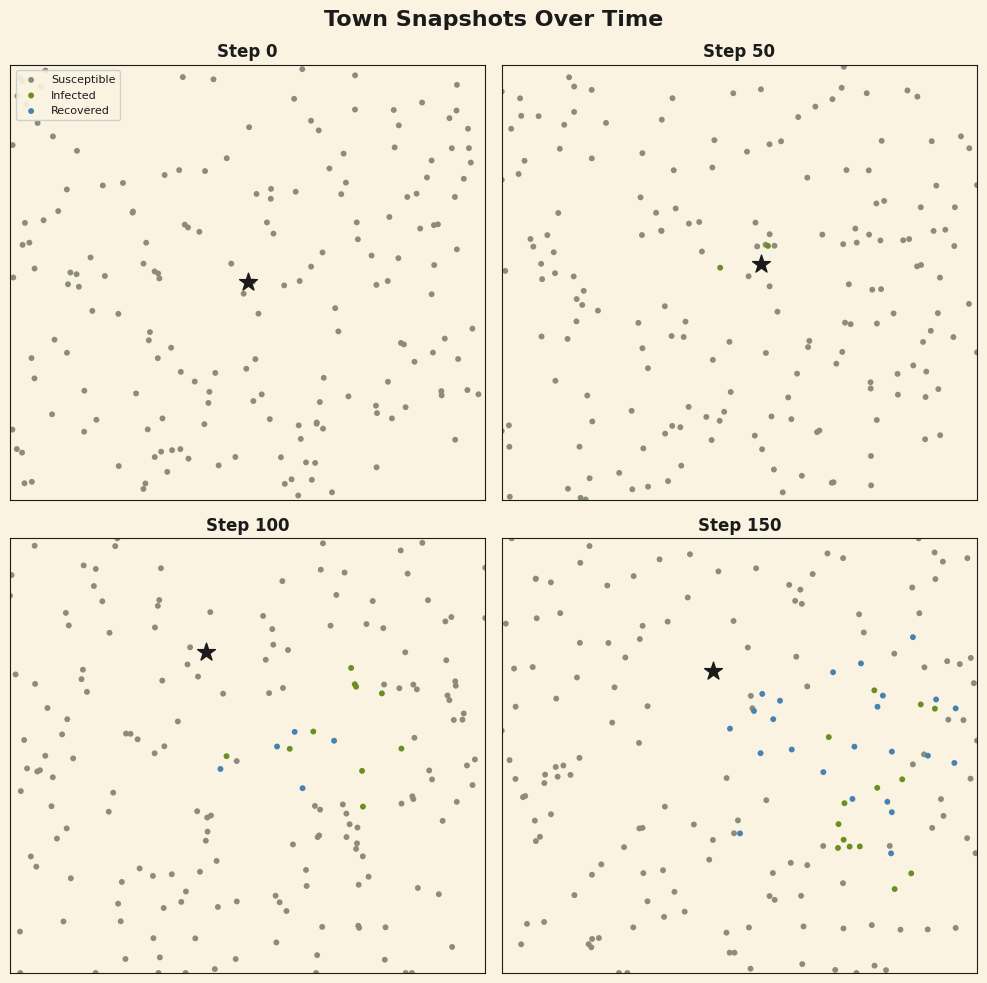

In [3]:
snapshot_steps = [0, N_STEPS // 3, 2 * N_STEPS // 3, N_STEPS]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, t in zip(axes.flat, snapshot_steps):
    pos_t, state_t = position_history[t], state_history[t]
    for i, name in enumerate(STATE_NAMES):
        mask = state_t == i
        ax.scatter(pos_t[mask, 0], pos_t[mask, 1], color=STATE_COLORS[name], s=18,
                   label=name, edgecolors="none")
    ax.scatter(*position_history[t, patient_zero], color=PALETTE["black"],
               marker="*", s=180, zorder=3)
    ax.set_xlim(0, TOWN_SIZE); ax.set_ylim(0, TOWN_SIZE)
    ax.set_title(f"Step {t}", fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])

axes[0, 0].legend(loc="upper left", fontsize=8, framealpha=0.9)
fig.suptitle("Town Snapshots Over Time", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("03_town_snapshots.png", dpi=150, facecolor=PALETTE["cream"])
plt.show()

### Visual 4 — SIR curves

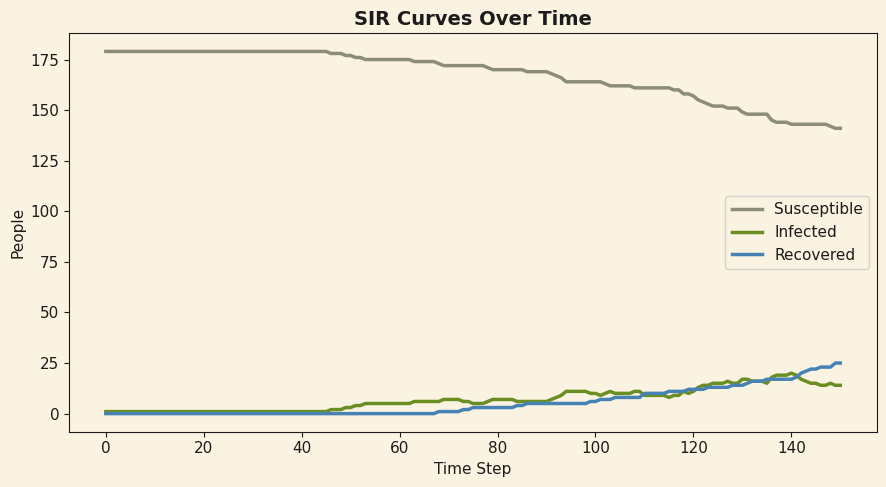

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
steps = np.arange(N_STEPS + 1)
for i, name in enumerate(STATE_NAMES):
    ax.plot(steps, sir_counts[:, i], color=STATE_COLORS[name], linewidth=2.5, label=name)
ax.set_xlabel("Time Step")
ax.set_ylabel("People")
ax.set_title("SIR Curves Over Time")
ax.legend()
plt.tight_layout()
plt.savefig("04_sir_curves.png", dpi=150, facecolor=PALETTE["cream"])
plt.show()

### Up next

Notebook 3 digs into the outbreak's geometry: how fast the infection frontier actually expands, where it concentrated, and who's left standing.